# Red Neuronal Informada por Física (PINN) — Ecuación de Difusión de Calor 1D
## Problema del documento MELIN — Fronteras Mixtas

**Ecuación gobernante** (ec. 1 del documento):
$$\frac{\partial T}{\partial t} = \alpha^2 \frac{\partial^2 T}{\partial x^2}, \quad x \in (0, l),\; t > 0$$

**Condiciones de frontera MIXTAS** (ec. 2 del documento):
$$T(0,\, t) = 0 \quad \text{(Dirichlet — temperatura fija)}$$
$$\left.\frac{\partial T}{\partial x}\right|_{x=l} = 0 \quad \text{(Neumann — frontera aislante)}$$

**Condición inicial** (ec. 7 del documento):
$$T(x,\, 0) = 100 \;\text{°C} \quad \text{(uniforme en todo el dominio)}$$

**Solución analítica** (ec. 3 del documento):
$$T(x,t) = \frac{400}{\pi}\sum_{n=0}^{\infty}\frac{1}{2n+1}\sin\!\left(\frac{2n+1}{2l}\pi x\right)\exp\!\left(-\alpha^2\left(\frac{2n+1}{2l}\pi\right)^2 t\right)$$

---

## ⚠️ Diferencia crítica respecto a la versión anterior

| Aspecto | Versión anterior (incorrecta) | **Esta versión (correcta)** |
|---|---|---|
| **CI** | Serie de Fourier en t=0 | **T(x,0) = 100** (uniforme) |
| **CF en x=L** | T(L,t) = 0 (Dirichlet) | **∂T/∂x\|ₓ₌ₗ = 0** (Neumann) |
| **Residuo CF derecha** | MSE de temperatura | **MSE de gradiente** (GradientTape) |

La caída brusca en x=1 de la versión anterior era exactamente por imponer T(L,t)=0 cuando físicamente esa frontera es **aislante** (flujo nulo).

---

## Función de pérdida PINN corregida

$$\boxed{\mathcal{L}_{\text{total}} =
  w_d\underbrace{\mathcal{L}_{\text{datos}}}_{\text{MSE vs analítica}} +
  w_r\underbrace{\mathcal{L}_{\text{PDE}}}_{\partial_t T - \alpha^2\partial_{xx}T=0} +
  w_i\underbrace{\mathcal{L}_{\text{CI}}}_{T(x,0)=100} +
  w_{bD}\underbrace{\mathcal{L}_{\text{CF-Dir}}}_{T(0,t)=0} +
  w_{bN}\underbrace{\mathcal{L}_{\text{CF-Neu}}}_{\partial_x T|_{x=l}=0}}$$

---

## Las tres arquitecturas PINN
| Modelo | Capas ocultas | Neuronas/capa | Activación | Parámetros aprox. |
|---|---|---|---|---|
| **PINN-A** — Shallow | 3 | 32 | tanh | ~2 200 |
| **PINN-B** — Medium  | 5 | 64 | tanh | ~20 700 |
| **PINN-C** — Deep    | 7 | 128 | tanh | ~100 000 |

> **¿Por qué `tanh`?** La condición de Neumann requiere calcular ∂T/∂x con GradientTape. `tanh` es infinitamente diferenciable, garantizando gradientes suaves en toda la red.

## Celda 1 — Importaciones y configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib import cm
import time
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Semilla global para reproducibilidad ─────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Parámetros físicos del problema (documento MELIN) ────────
alpha  = 0.2    # difusividad térmica α [m²/s]
L      = 1.0    # ancho de la pared l [m]
T_MAX  = 30.0   # tiempo máximo de simulación [s]
T_IC   = 100.0  # temperatura inicial uniforme T(x,0) = 100 °C

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU disponible     : {len(tf.config.list_physical_devices('GPU')) > 0}")
print()
print("Parámetros físicos (documento MELIN):")
print(f"  α = {alpha}  (difusividad térmica)")
print(f"  l = {L}    (ancho de la pared)")
print(f"  T(x,0) = {T_IC} °C  (CI uniforme)")
print(f"  T(0,t) = 0    (CF Dirichlet)")
print(f"  ∂T/∂x|_{{x=l}} = 0  (CF Neumann — aislante)")

TensorFlow version : 2.21.0
Keras version      : 3.13.2
GPU disponible     : True

Parámetros físicos (documento MELIN):
  α = 0.2  (difusividad térmica)
  l = 1.0    (ancho de la pared)
  T(x,0) = 100.0 °C  (CI uniforme)
  T(0,t) = 0    (CF Dirichlet)
  ∂T/∂x|_{x=l} = 0  (CF Neumann — aislante)


## Celda 2 — Solución analítica y generación de puntos de colocación

### Tipos de puntos para la PINN

| Tipo | Cantidad | Condición impuesta |
|---|---|---|
| **Interior** (colocación) | 5 000 | Residuo PDE = 0 |
| **CI** (t = 0) | 400 | T(x, 0) = 100 |
| **CF Dirichlet** (x = 0) | 400 | T(0, t) = 0 |
| **CF Neumann** (x = L) | 400 | ∂T/∂x\|ₓ₌ₗ = 0 |
| **Datos** (analítica muestreada) | 1 500 | Supervisión |

> La **frontera Neumann** ya no impone el valor de T sino el de su derivada espacial. Esto corrige la caída brusca en x=L.

In [2]:
# ══════════════════════════════════════════════════════════════
#  SOLUCIÓN ANALÍTICA (ec. 3 del documento)
#  T(x,t) = (400/π) Σ 1/(2n+1) sin((2n+1)πx/2l) exp(-α²((2n+1)π/2l)²t)
# ══════════════════════════════════════════════════════════════
def T_analitica(x, t, n_terms=50):
    """Solución analítica del documento MELIN (ec. 3)."""
    T = np.zeros_like(x, dtype=float)
    for n in range(n_terms):
        k = (2*n + 1) * np.pi / (2*L)
        T += (1.0/(2*n+1)) * np.sin(k*x) * np.exp(-alpha**2 * k**2 * t)
    return (400.0/np.pi) * T

# Verificación: T(x,0) debe ser ≈ 100 en el interior
x_test = np.linspace(0.01, L-0.01, 5)
print("Verificación solución analítica en t=0 (debe ser ≈ 100):")
for xi in x_test:
    print(f"  T(x={xi:.2f}, t=0) = {T_analitica(np.array([xi]), 0.0)[0]:.4f} °C")

# Verificación condición Neumann: ∂T/∂x|_{x=L} ≈ 0
dx_small = 1e-5
dTdx_L = (T_analitica(np.array([L]), 5.0)[0] - 
           T_analitica(np.array([L - dx_small]), 5.0)[0]) / dx_small
print(f"\nVerificación Neumann: ∂T/∂x|_{{x=L}} en t=5 = {dTdx_L:.6f} (debe ser ≈ 0)")

print()

# ══════════════════════════════════════════════════════════════
#  PUNTOS DE COLOCACIÓN (INTERIOR — residuo PDE)
# ══════════════════════════════════════════════════════════════
N_COLLOC = 5000
t_coll = np.random.uniform(0, T_MAX, N_COLLOC).astype(np.float32)
x_coll = np.random.uniform(0, L,     N_COLLOC).astype(np.float32)

# ══════════════════════════════════════════════════════════════
#  CONDICIÓN INICIAL: T(x, 0) = 100 °C  (UNIFORME)
#  Corrección respecto a versión anterior: ya no es serie de Fourier
# ══════════════════════════════════════════════════════════════
N_IC = 400
x_ic = np.linspace(0, L, N_IC).astype(np.float32)
t_ic = np.zeros(N_IC, dtype=np.float32)
T_ic = np.full(N_IC, T_IC, dtype=np.float32)   # T(x,0) = 100 (UNIFORME)

# ══════════════════════════════════════════════════════════════
#  CF DIRICHLET: T(0, t) = 0  (frontera izquierda — temperatura fija)
# ══════════════════════════════════════════════════════════════
N_BC = 400
t_bc_dir = np.random.uniform(0, T_MAX, N_BC).astype(np.float32)
x_bc_dir = np.zeros(N_BC, dtype=np.float32)    # x = 0
T_bc_dir = np.zeros(N_BC, dtype=np.float32)    # T = 0

# ══════════════════════════════════════════════════════════════
#  CF NEUMANN: ∂T/∂x|_{x=L} = 0  (frontera derecha — aislante)
#  Corrección respecto a versión anterior:
#  No se impone T(L,t)=0 sino el GRADIENTE = 0
# ══════════════════════════════════════════════════════════════
t_bc_neu = np.random.uniform(0, T_MAX, N_BC).astype(np.float32)
x_bc_neu = np.full(N_BC, L, dtype=np.float32)  # x = L
# (no hay valor objetivo de T, sólo de ∂T/∂x = 0)

# ══════════════════════════════════════════════════════════════
#  DATOS DE SUPERVISIÓN (solución analítica muestreada)
# ══════════════════════════════════════════════════════════════
N_DATA = 1500
t_data = np.random.uniform(0, T_MAX, N_DATA).astype(np.float32)
x_data = np.random.uniform(0, L,     N_DATA).astype(np.float32)
T_data = T_analitica(x_data, t_data).astype(np.float32)

print("Puntos de colocación generados:")
print(f"  Interior  (residuo PDE)         : {N_COLLOC:5d} puntos")
print(f"  CI        T(x,0)=100            : {N_IC:5d} puntos")
print(f"  CF-Dir    T(0,t)=0              : {N_BC:5d} puntos")
print(f"  CF-Neu    ∂T/∂x|_{{x=L}}=0       : {N_BC:5d} puntos")
print(f"  Datos     supervisados          : {N_DATA:5d} puntos")
print(f"  TOTAL                           : {N_COLLOC+N_IC+2*N_BC+N_DATA:5d} puntos")

Verificación solución analítica en t=0 (debe ser ≈ 100):
  T(x=0.01, t=0) = 87.2665 °C
  T(x=0.26, t=0) = 101.1259 °C
  T(x=0.50, t=0) = 100.9000 °C
  T(x=0.74, t=0) = 100.4909 °C
  T(x=0.99, t=0) = 100.0001 °C

Verificación Neumann: ∂T/∂x|_{x=L} en t=5 = 0.000903 (debe ser ≈ 0)

Puntos de colocación generados:
  Interior  (residuo PDE)         :  5000 puntos
  CI        T(x,0)=100            :   400 puntos
  CF-Dir    T(0,t)=0              :   400 puntos
  CF-Neu    ∂T/∂x|_{x=L}=0       :   400 puntos
  Datos     supervisados          :  1500 puntos
  TOTAL                           :  7700 puntos


## Celda 3 — Definición de las tres arquitecturas PINN

Todas usan `tanh` — necesario para que el GradientTape pueda calcular ∂T/∂x en la condición de Neumann.

| Modelo | Capas ocultas | Neuronas | Activación |
|---|---|---|---|
| **PINN-A** | 3 | 32 | tanh |
| **PINN-B** | 5 | 64 | tanh |
| **PINN-C** | 7 | 128→64→32 | tanh |

In [3]:
def build_pinn_A():
    """
    PINN-A — Shallow (3 capas ocultas, 32 neuronas)
    Red compacta. Activación tanh para derivadas suaves.
    Entrada: (t, x) → Salida: T(t, x)
    """
    inp = keras.Input(shape=(2,), name='input_tx')
    x = layers.Dense(32, activation='tanh', name='hidden_1')(inp)
    x = layers.Dense(32, activation='tanh', name='hidden_2')(x)
    x = layers.Dense(32, activation='tanh', name='hidden_3')(x)
    out = layers.Dense(1, activation='linear', name='T_output')(x)
    return keras.Model(inp, out, name='PINN_A_Shallow')


def build_pinn_B():
    """
    PINN-B — Medium (5 capas ocultas, 64 neuronas)
    Regularización L2 para estabilizar el entrenamiento con
    pérdida mixta (Dirichlet + Neumann + PDE + CI).
    """
    l2 = regularizers.l2(1e-5)
    inp = keras.Input(shape=(2,), name='input_tx')
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_1')(inp)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_2')(x)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_3')(x)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_4')(x)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_5')(x)
    out = layers.Dense(1, activation='linear', name='T_output')(x)
    return keras.Model(inp, out, name='PINN_B_Medium')


def build_pinn_C():
    """
    PINN-C — Deep (7 capas ocultas, arquitectura piramidal 128→64→32)
    Máxima expresividad. La arquitectura piramidal ayuda a capturar
    tanto los detalles finos (CI uniforme) como la forma global.
    """
    l2 = regularizers.l2(1e-5)
    inp = keras.Input(shape=(2,), name='input_tx')
    x = layers.Dense(128, activation='tanh', kernel_regularizer=l2, name='hidden_1')(inp)
    x = layers.Dense(128, activation='tanh', kernel_regularizer=l2, name='hidden_2')(x)
    x = layers.Dense(128, activation='tanh', kernel_regularizer=l2, name='hidden_3')(x)
    x = layers.Dense(64,  activation='tanh', kernel_regularizer=l2, name='hidden_4')(x)
    x = layers.Dense(64,  activation='tanh', kernel_regularizer=l2, name='hidden_5')(x)
    x = layers.Dense(32,  activation='tanh', kernel_regularizer=l2, name='hidden_6')(x)
    x = layers.Dense(32,  activation='tanh', kernel_regularizer=l2, name='hidden_7')(x)
    out = layers.Dense(1, activation='linear', name='T_output')(x)
    return keras.Model(inp, out, name='PINN_C_Deep')


model_A = build_pinn_A()
model_B = build_pinn_B()
model_C = build_pinn_C()

for nombre, m in [('PINN-A — Shallow (3×32)',   model_A),
                  ('PINN-B — Medium  (5×64)',   model_B),
                  ('PINN-C — Deep    (7×128)',  model_C)]:
    print(f"\n{'─'*50}")
    print(f"  {nombre}")
    print(f"  Parámetros totales: {m.count_params():,}")
    m.summary()


──────────────────────────────────────────────────
  PINN-A — Shallow (3×32)
  Parámetros totales: 2,241


Model: "PINN_A_Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tx (InputLayer)           │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ T_output (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

...

Model: "PINN_C_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tx (InputLayer)           │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_6 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_7 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ T_output (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,993 (191.38 KB)

 Trainable params: 48,993 (191.38 KB)

 Non-trainable params: 0 (0.00 B)

## Celda 4 — Función de pérdida PINN con fronteras mixtas

### Pesos de cada término

| Término | Fórmula | Peso | Justificación |
|---|---|---|---|
| $\mathcal{L}_{\text{datos}}$ | MSE(T̂, T_analítica) | `w_data = 1.0` | Anclaje a solución numérica |
| $\mathcal{L}_{\text{PDE}}$ | MSE(∂ₜT̂ − α²∂ₓₓT̂, 0) | `w_pde = 1.0` | Satisfacer ec. de difusión |
| $\mathcal{L}_{\text{CI}}$ | MSE(T̂(x,0), 100) | `w_ic = 10.0` | CI uniforme — peso alto |
| $\mathcal{L}_{\text{CF-Dir}}$ | MSE(T̂(0,t), 0) | `w_bc_dir = 10.0` | Dirichlet x=0 — peso alto |
| $\mathcal{L}_{\text{CF-Neu}}$ | MSE(∂T̂/∂x\|ₓ₌ₗ, 0) | `w_bc_neu = 10.0` | **Neumann x=L** — gradiente nulo |

> **Clave:** La CF-Neumann usa GradientTape para calcular ∂T̂/∂x y forzarla a cero, en lugar de forzar T(L,t)=0.

In [4]:
# ══════════════════════════════════════════════════════════════
#  PESOS DE LA FUNCIÓN DE PÉRDIDA PINN
# ══════════════════════════════════════════════════════════════
#
#  w_data    : peso del error en datos supervisados
#  w_pde     : peso del residuo de la PDE  (∂T/∂t - α²∂²T/∂x²)
#  w_ic      : peso del error en CI        T(x,0) = 100
#  w_bc_dir  : peso del error CF Dirichlet T(0,t) = 0
#  w_bc_neu  : peso del error CF Neumann   ∂T/∂x|_{x=L} = 0
#
W_DATA   = 1.0    # datos numéricos / analíticos
W_PDE    = 1.0    # residuo de la EDP
W_IC     = 10.0   # condición inicial uniforme — peso alto
W_BC_DIR = 10.0   # CF Dirichlet (x=0) — peso alto
W_BC_NEU = 10.0   # CF Neumann   (x=L) — peso alto (GRADIENTE, no temperatura)

print("╔══════════════════════════════════════════════════════╗")
print("║          PESOS DE LA PÉRDIDA PINN (v2)              ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  w_data    (datos numéricos)      = {W_DATA:6.2f}          ║")
print(f"║  w_pde     (residuo PDE)          = {W_PDE:6.2f}          ║")
print(f"║  w_ic      (CI: T(x,0)=100)       = {W_IC:6.2f}         ║")
print(f"║  w_bc_dir  (CF Dir: T(0,t)=0)     = {W_BC_DIR:6.2f}         ║")
print(f"║  w_bc_neu  (CF Neu: dT/dx|_L=0)   = {W_BC_NEU:6.2f}         ║")
print("╚══════════════════════════════════════════════════════╝")


# ══════════════════════════════════════════════════════════════
#  RESIDUO DE LA PDE  (GradientTape anidado)
# ══════════════════════════════════════════════════════════════
@tf.function
def pinn_residual(model, t_in, x_in):
    """
    Calcula el residuo: r = ∂T/∂t  -  α² ∂²T/∂x²
    usando diferenciación automática exacta.
    """
    t_tf = tf.cast(tf.reshape(t_in, (-1,1)), tf.float32)
    x_tf = tf.cast(tf.reshape(x_in, (-1,1)), tf.float32)

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([t_tf, x_tf])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([t_tf, x_tf])
            T_pred = model(tf.concat([t_tf, x_tf], axis=1), training=True)
        dT_dt = tape1.gradient(T_pred, t_tf)
        dT_dx = tape1.gradient(T_pred, x_tf)
    d2T_dx2 = tape2.gradient(dT_dx, x_tf)
    del tape1, tape2

    return dT_dt - alpha**2 * d2T_dx2


# ══════════════════════════════════════════════════════════════
#  GRADIENTE ESPACIAL EN x=L  (para condición de Neumann)
# ══════════════════════════════════════════════════════════════
@tf.function
def neumann_residual(model, t_in, x_in):
    """
    Calcula ∂T/∂x en los puntos de frontera Neumann (x=L).
    Debe ser ≈ 0 (frontera aislante).
    """
    t_tf = tf.cast(tf.reshape(t_in, (-1,1)), tf.float32)
    x_tf = tf.cast(tf.reshape(x_in, (-1,1)), tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x_tf)
        T_pred = model(tf.concat([t_tf, x_tf], axis=1), training=True)
    dT_dx = tape.gradient(T_pred, x_tf)
    return dT_dx


# ══════════════════════════════════════════════════════════════
#  FUNCIÓN DE PÉRDIDA TOTAL PINN (fronteras mixtas)
# ══════════════════════════════════════════════════════════════
@tf.function
def pinn_loss(model,
              t_coll, x_coll,
              t_ic, x_ic, T_ic,
              t_bc_dir, x_bc_dir, T_bc_dir,
              t_bc_neu, x_bc_neu,
              t_data, x_data, T_data):
    """
    Pérdida total PINN con fronteras mixtas:
        L = w_data   * L_datos
          + w_pde    * L_residuo_PDE
          + w_ic     * L_CI            (T(x,0) = 100)
          + w_bc_dir * L_CF_Dirichlet  (T(0,t) = 0)
          + w_bc_neu * L_CF_Neumann    (∂T/∂x|_{x=L} = 0)
    """
    # ── 1. Error en datos supervisados ────────────────────────
    inp_data = tf.concat([tf.reshape(t_data,(-1,1)),
                          tf.reshape(x_data,(-1,1))], axis=1)
    T_pred_data = model(inp_data, training=True)
    L_data = tf.reduce_mean(tf.square(
        T_pred_data - tf.reshape(T_data,(-1,1))))

    # ── 2. Residuo de la PDE (puntos interiores) ──────────────
    res = pinn_residual(model, t_coll, x_coll)
    L_pde = tf.reduce_mean(tf.square(res))

    # ── 3. Condición inicial: T(x, 0) = 100 ──────────────────
    inp_ic = tf.concat([tf.reshape(t_ic,(-1,1)),
                        tf.reshape(x_ic,(-1,1))], axis=1)
    T_pred_ic = model(inp_ic, training=True)
    L_ic = tf.reduce_mean(tf.square(
        T_pred_ic - tf.reshape(T_ic,(-1,1))))

    # ── 4. CF Dirichlet: T(0, t) = 0 ─────────────────────────
    inp_dir = tf.concat([tf.reshape(t_bc_dir,(-1,1)),
                         tf.reshape(x_bc_dir,(-1,1))], axis=1)
    T_pred_dir = model(inp_dir, training=True)
    L_bc_dir = tf.reduce_mean(tf.square(
        T_pred_dir - tf.reshape(T_bc_dir,(-1,1))))

    # ── 5. CF Neumann: ∂T/∂x|_{x=L} = 0 ─────────────────────
    #    Se calcula el gradiente y se fuerza a cero
    dT_dx_L = neumann_residual(model, t_bc_neu, x_bc_neu)
    L_bc_neu = tf.reduce_mean(tf.square(dT_dx_L))

    # ── 6. Pérdida total ponderada ────────────────────────────
    L_total = (W_DATA   * L_data    +
               W_PDE    * L_pde     +
               W_IC     * L_ic      +
               W_BC_DIR * L_bc_dir  +
               W_BC_NEU * L_bc_neu)

    return L_total, L_data, L_pde, L_ic, L_bc_dir, L_bc_neu


print("\nFunción de pérdida PINN (fronteras mixtas) compilada.")
print(f"  CF izquierda (x=0): Dirichlet — T(0,t) = 0")
print(f"  CF derecha   (x=L): Neumann   — ∂T/∂x = 0  (aislante)")
print(f"  CI                : T(x,0) = {T_IC} °C (uniforme)")

╔══════════════════════════════════════════════════════╗
║          PESOS DE LA PÉRDIDA PINN (v2)              ║
╠══════════════════════════════════════════════════════╣
║  w_data    (datos numéricos)      =   1.00          ║
║  w_pde     (residuo PDE)          =   1.00          ║
║  w_ic      (CI: T(x,0)=100)       =  10.00         ║
║  w_bc_dir  (CF Dir: T(0,t)=0)     =  10.00         ║
║  w_bc_neu  (CF Neu: dT/dx|_L=0)   =  10.00         ║
╚══════════════════════════════════════════════════════╝

Función de pérdida PINN (fronteras mixtas) compilada.
  CF izquierda (x=0): Dirichlet — T(0,t) = 0
  CF derecha   (x=L): Neumann   — ∂T/∂x = 0  (aislante)
  CI                : T(x,0) = 100.0 °C (uniforme)


## Celda 5 — Conversión a tensores y bucle de entrenamiento

**Hiperparámetros de entrenamiento:**

| Parámetro | Valor | Nota |
|---|---|---|
| `EPOCHS` | 5 000 | Aumentar si la red no converge |
| `LR` | 1e-3 (decay) | Decay × 0.85 cada 500 pasos |
| `patience` | 500 | Early stopping |
| `verbose_every` | 500 | Imprimir cada N épocas |

In [5]:
# ── Convertir todos los arrays a tensores TF ──────────────────
def to_tf(*arrs):
    return [tf.constant(a, dtype=tf.float32) for a in arrs]

(t_coll_tf, x_coll_tf,
 t_ic_tf, x_ic_tf, T_ic_tf,
 t_bc_dir_tf, x_bc_dir_tf, T_bc_dir_tf,
 t_bc_neu_tf, x_bc_neu_tf,
 t_data_tf, x_data_tf, T_data_tf) = to_tf(
    t_coll, x_coll,
    t_ic, x_ic, T_ic,
    t_bc_dir, x_bc_dir, T_bc_dir,
    t_bc_neu, x_bc_neu,
    t_data, x_data, T_data
)


def entrenar_pinn(model, nombre, epochs=5000, lr=1e-3,
                  patience=500, verbose_every=500):
    """
    Bucle de entrenamiento personalizado para PINN con fronteras mixtas.
    Registra la pérdida total y cada componente por separado:
      hist['total'], ['data'], ['pde'], ['ic'], ['bc_dir'], ['bc_neu']
    """
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr,
        decay_steps=500,
        decay_rate=0.85,
        staircase=True
    )
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

    hist = {'total':[], 'data':[], 'pde':[],
            'ic':[], 'bc_dir':[], 'bc_neu':[]}
    best_loss    = np.inf
    best_weights = None
    wait = 0
    t_start = time.perf_counter()

    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            L_total, L_d, L_r, L_i, L_bd, L_bn = pinn_loss(
                model,
                t_coll_tf, x_coll_tf,
                t_ic_tf, x_ic_tf, T_ic_tf,
                t_bc_dir_tf, x_bc_dir_tf, T_bc_dir_tf,
                t_bc_neu_tf, x_bc_neu_tf,
                t_data_tf, x_data_tf, T_data_tf
            )
        grads = tape.gradient(L_total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        l = float(L_total)
        hist['total'].append(l)
        hist['data'].append(float(L_d))
        hist['pde'].append(float(L_r))
        hist['ic'].append(float(L_i))
        hist['bc_dir'].append(float(L_bd))
        hist['bc_neu'].append(float(L_bn))

        # Early stopping
        if l < best_loss:
            best_loss    = l
            best_weights = [w.numpy() for w in model.trainable_variables]
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping en época {epoch}")
                break

        if epoch % verbose_every == 0 or epoch == 1:
            elapsed = time.perf_counter() - t_start
            print(f"  Época {epoch:5d}/{epochs} | "
                  f"L={l:.5f} | "
                  f"data={float(L_d):.4f} | "
                  f"pde={float(L_r):.4f} | "
                  f"ic={float(L_i):.4f} | "
                  f"dir={float(L_bd):.4f} | "
                  f"neu={float(L_bn):.4f} | "
                  f"t={elapsed:.1f}s")

    # Restaurar mejores pesos
    for var, val in zip(model.trainable_variables, best_weights):
        var.assign(val)

    t_total = time.perf_counter() - t_start
    print(f"  ✓ {nombre} — {len(hist['total'])} épocas, "
          f"mejor L={best_loss:.6f}, tiempo={t_total:.2f}s")
    return hist, t_total


print("Función de entrenamiento PINN (fronteras mixtas) definida.")
print(f"  Épocas máximas   : 5000  ← cambiar EPOCHS en Celda 6")
print(f"  LR inicial       : 1e-3  (decay × 0.85 cada 500 pasos)")
print(f"  Early stopping   : paciencia = 500  ← cambiar patience en Celda 6")

Función de entrenamiento PINN (fronteras mixtas) definida.
  Épocas máximas   : 5000  ← cambiar EPOCHS en Celda 6
  LR inicial       : 1e-3  (decay × 0.85 cada 500 pasos)
  Early stopping   : paciencia = 500  ← cambiar patience en Celda 6


## Celda 6 — Entrenamiento de las tres PINN ⬅️ Ajustar EPOCHS y patience aquí

In [6]:
# ══════════════════════════════════════════════════════════════
#  PARÁMETROS DE ENTRENAMIENTO — MODIFICAR AQUÍ
# ══════════════════════════════════════════════════════════════
EPOCHS        = 10000   # ← aumentar para mayor precisión (ej. 10000, 20000)
PATIENCE      = 800    # ← épocas sin mejora antes de parar (ej. 800, 1000)
LR            = 1e-3   # ← learning rate inicial
VERBOSE_EVERY = 500    # ← cada cuántas épocas imprimir

historiales   = {}
tiempos_train = {}

for nombre, modelo in [('PINN_A', model_A),
                        ('PINN_B', model_B),
                        ('PINN_C', model_C)]:
    print(f"\n{'#'*65}")
    print(f"  Entrenando {nombre}  "
          f"({modelo.count_params():,} parámetros) ...")
    print(f"{'#'*65}")

    hist, t_total = entrenar_pinn(
        modelo, nombre,
        epochs=EPOCHS,
        lr=LR,
        patience=PATIENCE,
        verbose_every=VERBOSE_EVERY
    )
    historiales[nombre]   = hist
    tiempos_train[nombre] = t_total

print("\n" + "="*65)
print("  TIEMPOS DE ENTRENAMIENTO")
print("="*65)
for k, v in tiempos_train.items():
    epocas = len(historiales[k]['total'])
    print(f"  {k} : {v:.2f} s  ({v/60:.2f} min)  — {epocas} épocas")


#################################################################
  Entrenando PINN_A  (2,241 parámetros) ...
#################################################################
  Época     1/10000 | L=100991.00781 | data=1361.7084 | pde=0.0005 | ic=9962.8760 | dir=0.0396 | neu=0.0144 | t=1.4s
  Época   500/10000 | L=58744.20312 | data=605.2366 | pde=10.9733 | ic=5793.4526 | dir=18.3713 | neu=0.9752 | t=14.2s
  Época  1000/10000 | L=40754.17969 | data=446.9536 | pde=17.8215 | ic=4014.7302 | dir=13.3213 | neu=0.8894 | t=26.8s
  Época  1500/10000 | L=29022.22070 | data=379.5399 | pde=41.5055 | ic=2848.7715 | dir=10.4137 | neu=0.9325 | t=39.4s
  Época  2000/10000 | L=21133.68359 | data=372.3677 | pde=67.9639 | ic=2059.3250 | dir=9.0609 | neu=0.9492 | t=51.9s
  Época  2500/10000 | L=15707.20117 | data=397.7843 | pde=94.5431 | ic=1513.0642 | dir=7.1179 | neu=1.3053 | t=64.4s
  Época  3000/10000 | L=11894.93750 | data=437.5074 | pde=120.2994 | ic=1126.9645 | dir=5.1884 | neu=1.5602 | t=77.1s


## Celda 7 — Evaluación de métricas en malla densa

In [7]:
# ── Malla densa de evaluación ─────────────────────────────────
t_eval = np.linspace(0, T_MAX, 200).astype(np.float32)
x_eval = np.linspace(0, L,     60).astype(np.float32)
TT, XX = np.meshgrid(t_eval, x_eval)

t_flat = TT.ravel()
x_flat = XX.ravel()
T_ref  = T_analitica(x_flat, t_flat).astype(np.float32)
inp_eval = np.column_stack([t_flat, x_flat]).astype(np.float32)

resultados = {}

for nombre, modelo in [('PINN_A', model_A),
                        ('PINN_B', model_B),
                        ('PINN_C', model_C)]:

    T_pred = modelo.predict(inp_eval, verbose=0).flatten()

    mse     = mean_squared_error(T_ref, T_pred)
    rmse    = np.sqrt(mse)
    mae     = mean_absolute_error(T_ref, T_pred)
    r2      = r2_score(T_ref, T_pred)
    max_err = np.max(np.abs(T_ref - T_pred))
    L_final = min(historiales[nombre]['total'])

    # Verificar condición Neumann en frontera derecha
    t_neu_check = np.linspace(0, T_MAX, 50).astype(np.float32)
    x_neu_check = np.full(50, L, dtype=np.float32)
    dTdx_check  = neumann_residual(
        modelo,
        tf.constant(t_neu_check),
        tf.constant(x_neu_check)
    ).numpy().flatten()

    resultados[nombre] = {
        'MSE'         : mse,
        'RMSE'        : rmse,
        'MAE'         : mae,
        'R2'          : r2,
        'Max_Error'   : max_err,
        'L_final'     : L_final,
        'Neu_MAE'     : np.mean(np.abs(dTdx_check)),  # cuánto viola Neumann
        'Tiempo_train': tiempos_train[nombre],
        'Epocas'      : len(historiales[nombre]['total']),
        'Params'      : modelo.count_params(),
        'y_pred'      : T_pred,
        'y_true'      : T_ref,
        'pred_malla'  : T_pred.reshape(TT.shape),
    }

# ── Tabla resumen ─────────────────────────────────────────────
df_res = pd.DataFrame({
    'Modelo'        : list(resultados.keys()),
    'Parámetros'    : [resultados[k]['Params']            for k in resultados],
    'Épocas'        : [resultados[k]['Epocas']            for k in resultados],
    'MSE [°C²]'     : [round(resultados[k]['MSE'],   4)   for k in resultados],
    'RMSE [°C]'     : [round(resultados[k]['RMSE'],  4)   for k in resultados],
    'MAE [°C]'      : [round(resultados[k]['MAE'],   4)   for k in resultados],
    'R²'            : [round(resultados[k]['R2'],    5)   for k in resultados],
    'MaxErr [°C]'   : [round(resultados[k]['Max_Error'],3) for k in resultados],
    '|∂T/∂x|_L| MAE': [round(resultados[k]['Neu_MAE'],5) for k in resultados],
    'T_train [s]'   : [round(resultados[k]['Tiempo_train'],2) for k in resultados],
})

print("\n" + "="*80)
print("  TABLA COMPARATIVA — MÉTRICAS VS. SOLUCIÓN ANALÍTICA (MELIN)")
print("="*80)
display(df_res)
print("\n  Columna '|∂T/∂x|_L| MAE': cuánto viola la CF Neumann (→ 0 es perfecto)")
mejor = df_res.loc[df_res['MAE [°C]'].idxmin(), 'Modelo']
print(f"\n  Mejor modelo por MAE: {mejor}")


  TABLA COMPARATIVA — MÉTRICAS VS. SOLUCIÓN ANALÍTICA (MELIN)


,Modelo,Parámetros,Épocas,MSE [°C²],RMSE [°C],MAE [°C],R²,MaxErr [°C],|∂T/∂x|_L| MAE,T_train [s]
0,PINN_A,2241,10000,883.0071,29.7154,18.3275,-0.25146,89.014999,1.37354,254.19
1,PINN_B,16897,10000,0.8984,0.9479,0.1126,0.99873,99.540001,0.02411,358.75
2,PINN_C,48993,10000,4.8204,2.1955,0.5812,0.99317,91.218002,0.02634,473.10



  Columna '|∂T/∂x|_L| MAE': cuánto viola la CF Neumann (→ 0 es perfecto)

  Mejor modelo por MAE: PINN_B


## Celda 8 — Gráfica 1: Curvas de pérdida por componente

Ahora hay **5 componentes** (datos, PDE, CI, CF-Dir, CF-Neu) en lugar de 4.

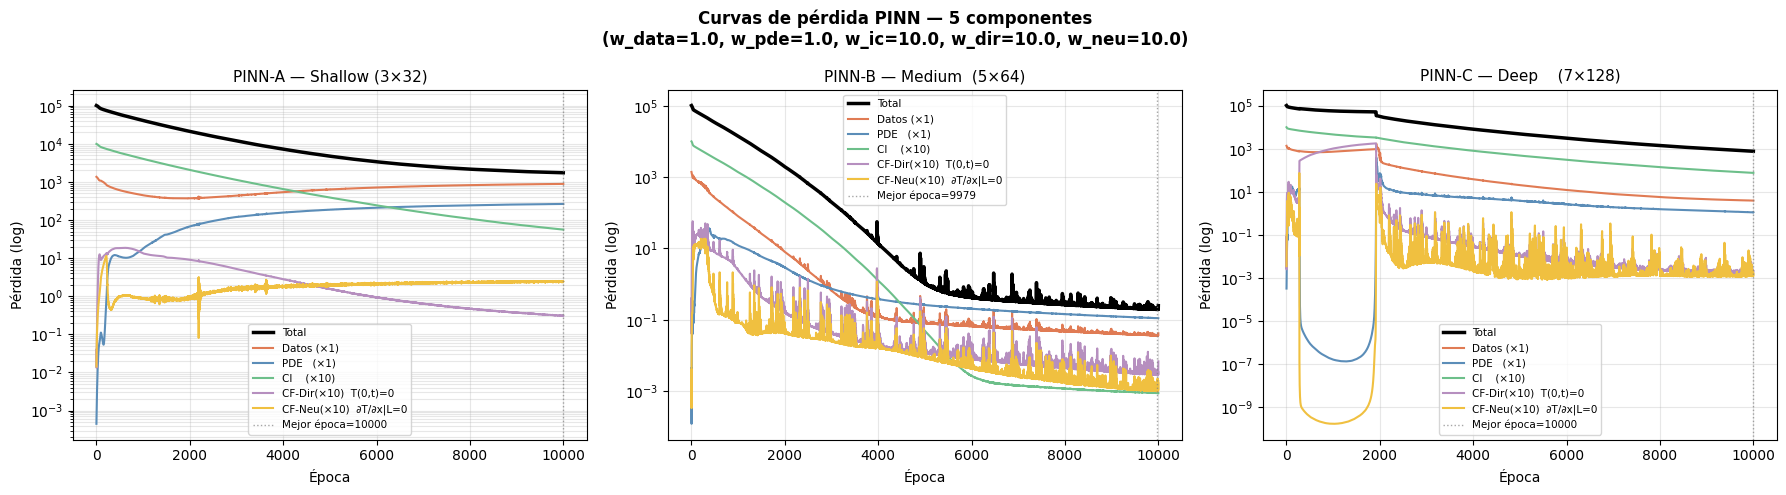

In [8]:
colores   = {'PINN_A': '#E07B54', 'PINN_B': '#5B8DB8', 'PINN_C': '#6DBF8A'}
etiquetas = {'PINN_A': 'PINN-A — Shallow (3×32)',
             'PINN_B': 'PINN-B — Medium  (5×64)',
             'PINN_C': 'PINN-C — Deep    (7×128)'}

col_comp = {
    'total' : 'black',
    'data'  : '#E07B54',
    'pde'   : '#5B8DB8',
    'ic'    : '#6DBF8A',
    'bc_dir': '#B68FBF',
    'bc_neu': '#F0C040'
}
lbl_comp = {
    'total' : 'Total',
    'data'  : f'Datos (×{W_DATA:.0f})',
    'pde'   : f'PDE   (×{W_PDE:.0f})',
    'ic'    : f'CI    (×{W_IC:.0f})',
    'bc_dir': f'CF-Dir(×{W_BC_DIR:.0f})  T(0,t)=0',
    'bc_neu': f'CF-Neu(×{W_BC_NEU:.0f})  ∂T/∂x|L=0'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, nombre in zip(axes, historiales):
    hist = historiales[nombre]
    ep   = range(1, len(hist['total'])+1)

    for comp in ['total','data','pde','ic','bc_dir','bc_neu']:
        lw = 2.5 if comp == 'total' else 1.5
        ax.semilogy(ep, hist[comp],
                    color=col_comp[comp], lw=lw,
                    label=lbl_comp[comp])

    best_ep = np.argmin(hist['total'])+1
    ax.axvline(best_ep, color='gray', lw=1, ls=':', alpha=0.7,
               label=f'Mejor época={best_ep}')

    ax.set_title(etiquetas[nombre], fontsize=11)
    ax.set_xlabel('Época', fontsize=10)
    ax.set_ylabel('Pérdida (log)', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle(
    f'Curvas de pérdida PINN — 5 componentes\n'
    f'(w_data={W_DATA}, w_pde={W_PDE}, w_ic={W_IC}, '
    f'w_dir={W_BC_DIR}, w_neu={W_BC_NEU})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('pinn_perdida_componentes.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 9 — Gráfica 2: Predicción vs Valor analítico (scatter)

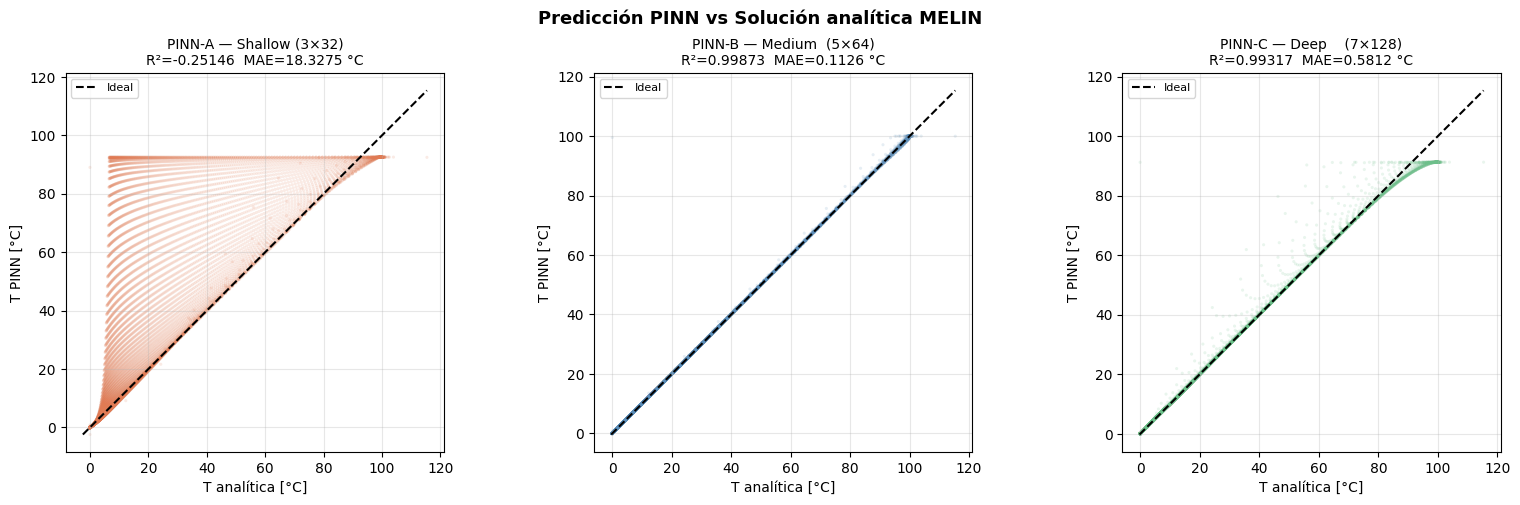

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, nombre in zip(axes, resultados):
    y_true = resultados[nombre]['y_true']
    y_pred = resultados[nombre]['y_pred']
    r2     = resultados[nombre]['R2']
    mae    = resultados[nombre]['MAE']
    col    = colores[nombre]

    ax.scatter(y_true, y_pred, alpha=0.15, s=5,
               color=col, edgecolors='none')
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Ideal')

    ax.set_xlabel('T analítica [°C]', fontsize=10)
    ax.set_ylabel('T PINN [°C]',      fontsize=10)
    ax.set_title(f"{etiquetas[nombre]}\nR²={r2:.5f}  MAE={mae:.4f} °C", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')

fig.suptitle('Predicción PINN vs Solución analítica MELIN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 10 — Gráfica 3: Superficies T(x,t) y mapas de error absoluto

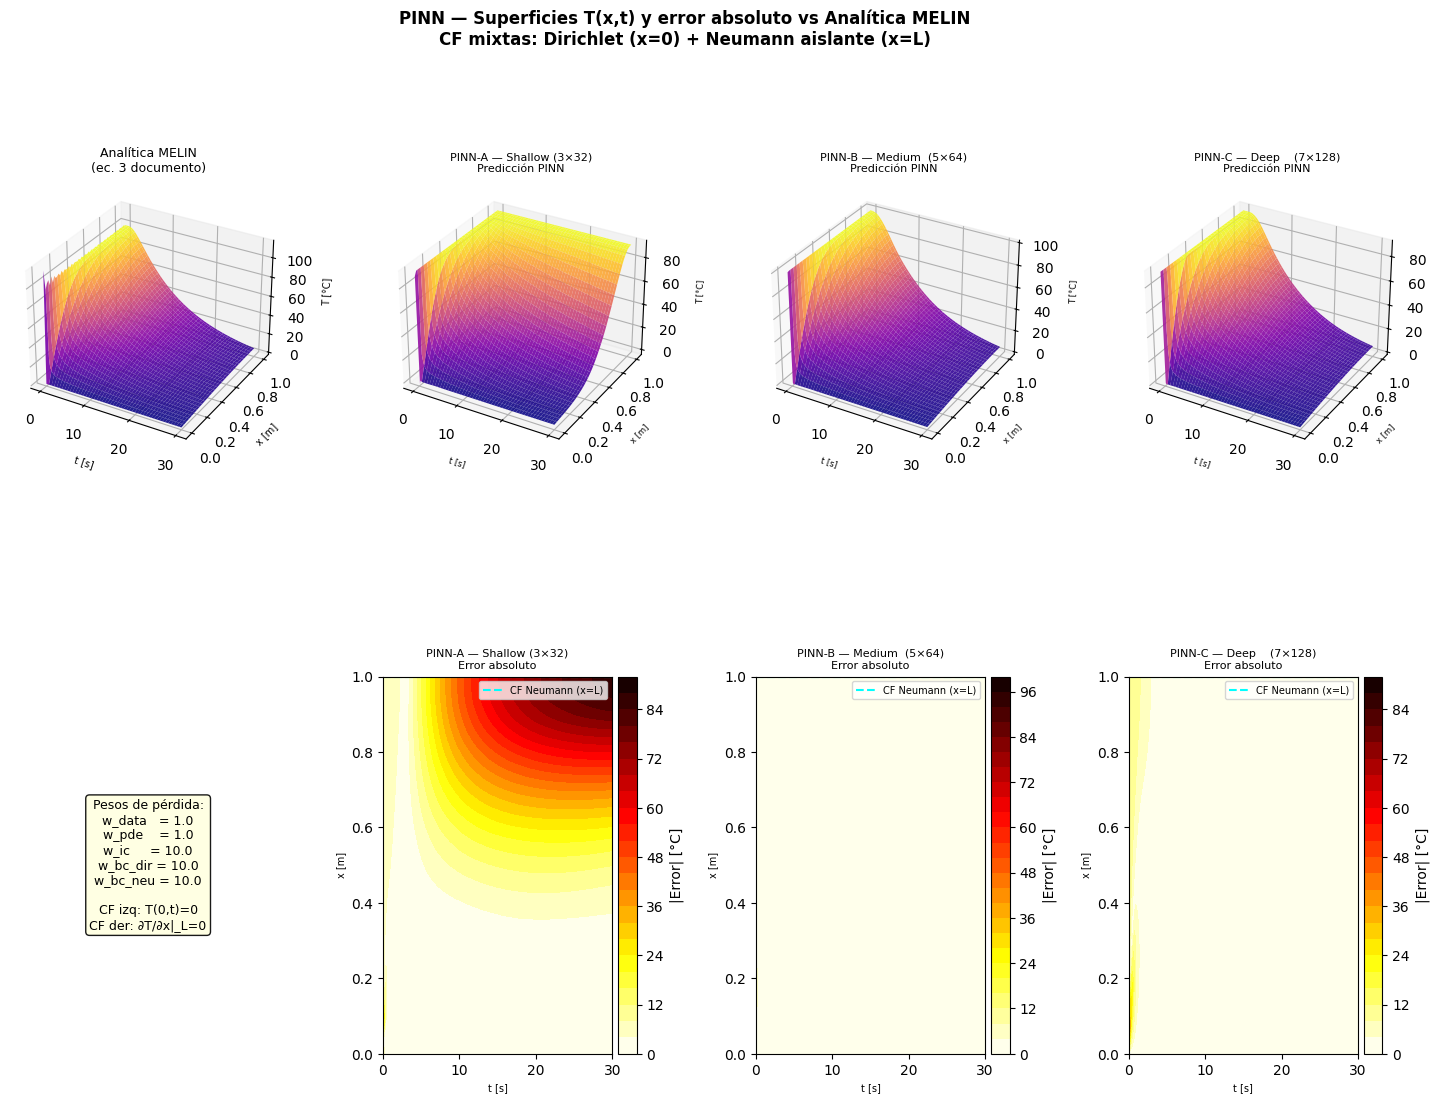

In [10]:
T_ref_malla = T_analitica(x_flat, t_flat).reshape(TT.shape)

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Solución analítica ────────────────────────────────────────
ax_ref = fig.add_subplot(gs[0, 0], projection='3d')
ax_ref.plot_surface(TT, XX, T_ref_malla, cmap=cm.plasma,
                    alpha=0.9, linewidth=0)
ax_ref.set_title('Analítica MELIN\n(ec. 3 documento)', fontsize=9)
ax_ref.set_xlabel('t [s]', fontsize=7)
ax_ref.set_ylabel('x [m]', fontsize=7)
ax_ref.set_zlabel('T [°C]', fontsize=7)

# ── Tres PINN + mapas de error ────────────────────────────────
for col_idx, (nombre, modelo) in enumerate(
        zip(resultados.keys(), [model_A, model_B, model_C])):

    pred_malla = resultados[nombre]['pred_malla']
    err        = np.abs(pred_malla - T_ref_malla)

    ax_s = fig.add_subplot(gs[0, col_idx+1], projection='3d')
    ax_s.plot_surface(TT, XX, pred_malla, cmap=cm.plasma,
                      alpha=0.9, linewidth=0)
    ax_s.set_title(f'{etiquetas[nombre]}\nPredicción PINN', fontsize=8)
    ax_s.set_xlabel('t [s]', fontsize=6)
    ax_s.set_ylabel('x [m]', fontsize=6)
    ax_s.set_zlabel('T [°C]', fontsize=6)

    ax_e = fig.add_subplot(gs[1, col_idx+1])
    im   = ax_e.contourf(TT, XX, err, levels=25, cmap='hot_r')
    fig.colorbar(im, ax=ax_e, label='|Error| [°C]', pad=0.02)
    ax_e.set_title(f'{etiquetas[nombre]}\nError absoluto', fontsize=8)
    ax_e.set_xlabel('t [s]', fontsize=7)
    ax_e.set_ylabel('x [m]', fontsize=7)
    # Marcar la frontera Neumann
    ax_e.axhline(L, color='cyan', lw=1.5, ls='--', label='CF Neumann (x=L)')
    ax_e.legend(fontsize=7)

ax_blank = fig.add_subplot(gs[1, 0])
ax_blank.axis('off')
ax_blank.text(0.5, 0.5,
    f'Pesos de pérdida:\n'
    f'w_data   = {W_DATA}\n'
    f'w_pde    = {W_PDE}\n'
    f'w_ic     = {W_IC}\n'
    f'w_bc_dir = {W_BC_DIR}\n'
    f'w_bc_neu = {W_BC_NEU}\n\n'
    f'CF izq: T(0,t)=0\n'
    f'CF der: ∂T/∂x|_L=0',
    ha='center', va='center', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

fig.suptitle(
    'PINN — Superficies T(x,t) y error absoluto vs Analítica MELIN\n'
    'CF mixtas: Dirichlet (x=0) + Neumann aislante (x=L)',
    fontsize=12, fontweight='bold')
plt.savefig('pinn_superficies.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 11 — Gráfica 4: Perfiles T(x) en tiempos seleccionados

Aquí se ve directamente si la PINN respeta la **condición Neumann**: las curvas deben llegar a x=L con **pendiente horizontal** (∂T/∂x = 0), no cayendo a cero.

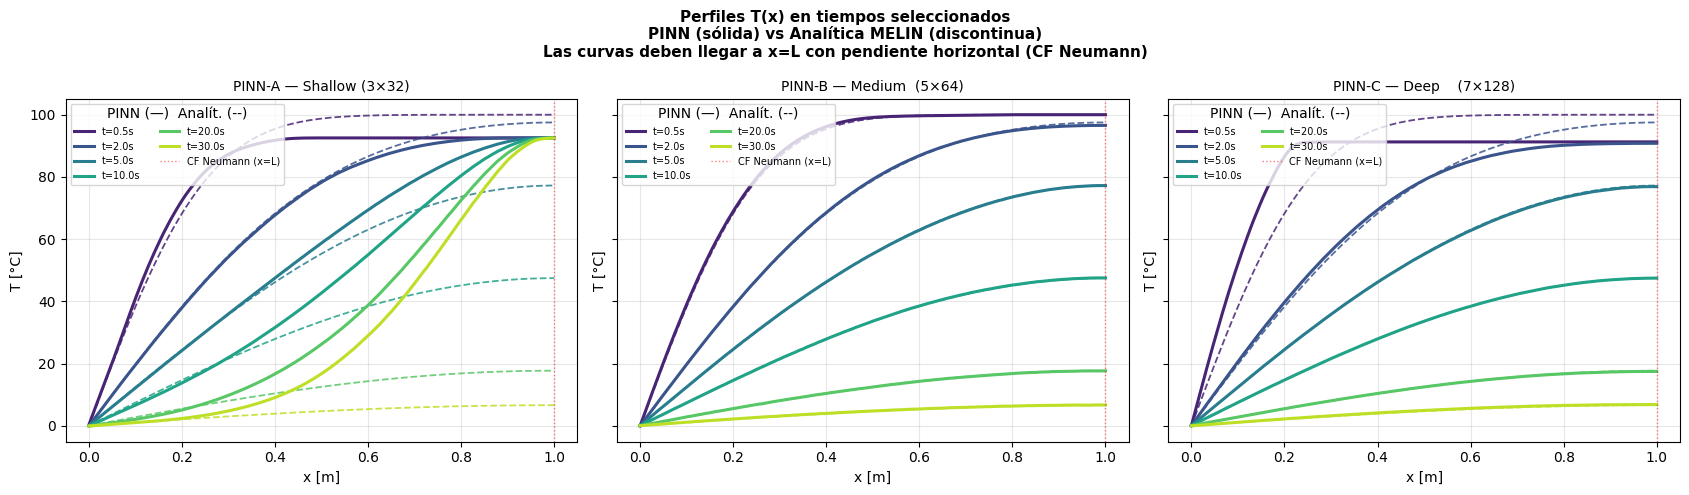

In [11]:
tiempos_eval = [0.5, 2.0, 5.0, 10.0, 20.0, 30.0]
x_prof       = np.linspace(0, L, 150).astype(np.float32)
colores_t    = plt.cm.viridis(np.linspace(0.1, 0.9, len(tiempos_eval)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    for t_ev, ct in zip(tiempos_eval, colores_t):
        T_an = T_analitica(x_prof, t_ev)
        ax.plot(x_prof, T_an, '--', color=ct, lw=1.3, alpha=0.85)

        inp  = np.column_stack([np.full_like(x_prof, t_ev), x_prof])
        pred = modelo.predict(inp, verbose=0).flatten()
        ax.plot(x_prof, pred, '-', color=ct, lw=2.2, label=f't={t_ev:.1f}s')

    # Marcar la frontera Neumann
    ax.axvline(L, color='red', lw=1, ls=':', alpha=0.5,
               label='CF Neumann (x=L)')

    ax.set_xlabel('x [m]',  fontsize=10)
    ax.set_ylabel('T [°C]', fontsize=10)
    ax.set_title(etiquetas[nombre], fontsize=10)
    ax.legend(fontsize=7, ncol=2, title='PINN (—)  Analít. (--)')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Perfiles T(x) en tiempos seleccionados\n'
    'PINN (sólida) vs Analítica MELIN (discontinua)\n'
    'Las curvas deben llegar a x=L con pendiente horizontal (CF Neumann)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_perfiles_temp.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 12 — Gráfica 5: Evolución temporal en nodos seleccionados

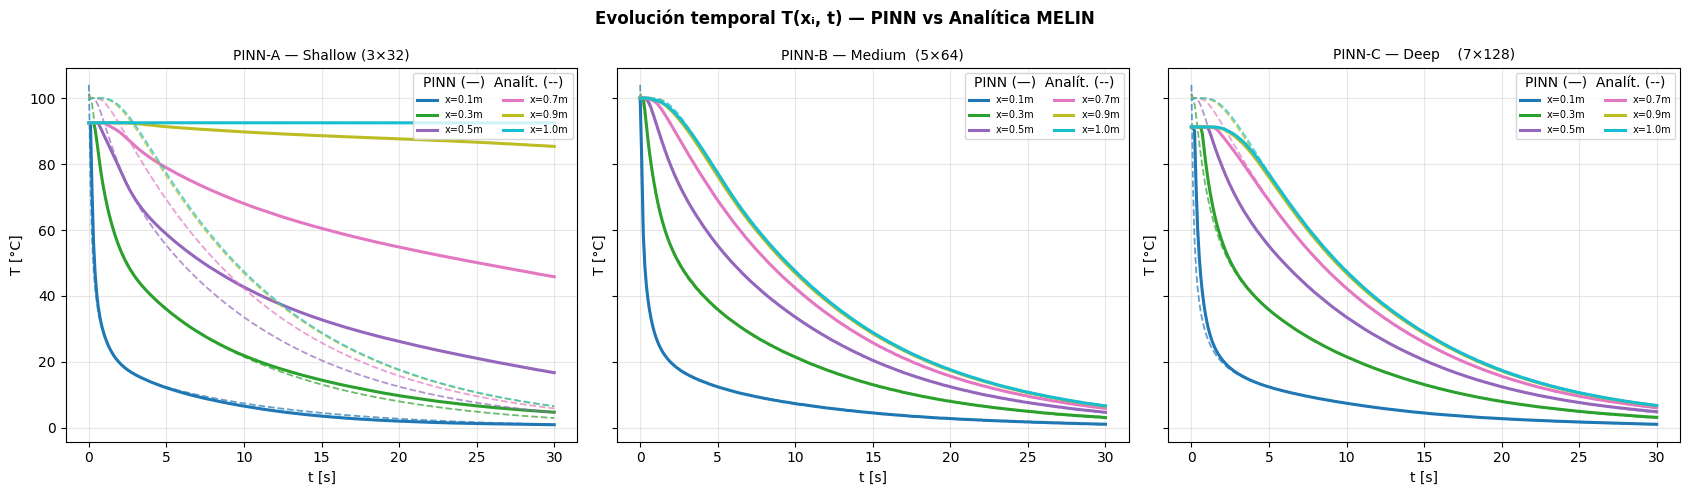

In [12]:
nodos_x  = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
t_evol   = np.linspace(0, T_MAX, 300).astype(np.float32)
col_nodo = plt.cm.tab10(np.linspace(0, 1, len(nodos_x)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    for xi, cn in zip(nodos_x, col_nodo):
        T_an = np.array([T_analitica(np.array([xi]), t)[0] for t in t_evol])
        ax.plot(t_evol, T_an, '--', color=cn, lw=1.3, alpha=0.7)

        inp  = np.column_stack([t_evol, np.full_like(t_evol, xi)])
        pred = modelo.predict(inp, verbose=0).flatten()
        ax.plot(t_evol, pred, '-', color=cn, lw=2.2,
                label=f'x={xi:.1f}m')

    ax.set_xlabel('t [s]',  fontsize=10)
    ax.set_ylabel('T [°C]', fontsize=10)
    ax.set_title(etiquetas[nombre], fontsize=10)
    ax.legend(fontsize=7, ncol=2, title='PINN (—)  Analít. (--)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Evolución temporal T(xᵢ, t) — PINN vs Analítica MELIN',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 13 — Gráfica 6: Verificación de la condición de Neumann

Esta gráfica es específica del problema MELIN: muestra si la PINN respeta ∂T/∂x|ₓ₌ₗ = 0 en todo el rango de tiempo.

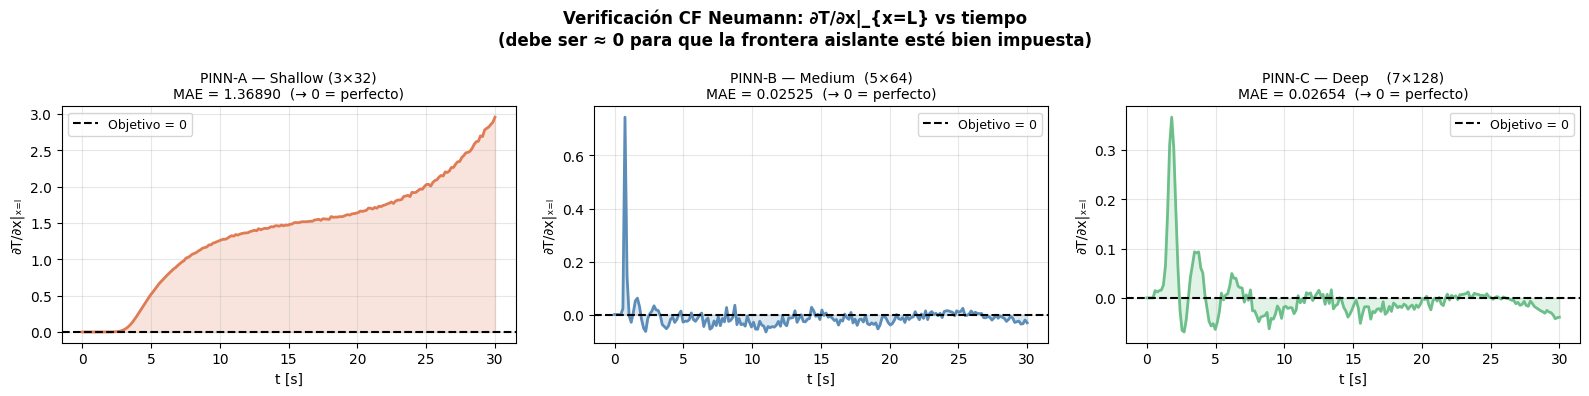

In [13]:
t_neu_check = np.linspace(0, T_MAX, 200).astype(np.float32)
x_neu_check = np.full(200, L, dtype=np.float32)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    dTdx = neumann_residual(
        modelo,
        tf.constant(t_neu_check),
        tf.constant(x_neu_check)
    ).numpy().flatten()

    ax.plot(t_neu_check, dTdx, color=colores[nombre], lw=2)
    ax.axhline(0, color='black', lw=1.5, ls='--', label='Objetivo = 0')
    ax.fill_between(t_neu_check, dTdx, 0,
                    alpha=0.2, color=colores[nombre])

    mae_neu = np.mean(np.abs(dTdx))
    ax.set_title(
        f'{etiquetas[nombre]}\n'
        f'MAE = {mae_neu:.5f}  (→ 0 = perfecto)',
        fontsize=10)
    ax.set_xlabel('t [s]', fontsize=10)
    ax.set_ylabel('∂T/∂x|ₓ₌ₗ', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Verificación CF Neumann: ∂T/∂x|_{x=L} vs tiempo\n'
    '(debe ser ≈ 0 para que la frontera aislante esté bien impuesta)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_neumann_check.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 14 — Gráfica 7: Residuo de la PDE en el dominio

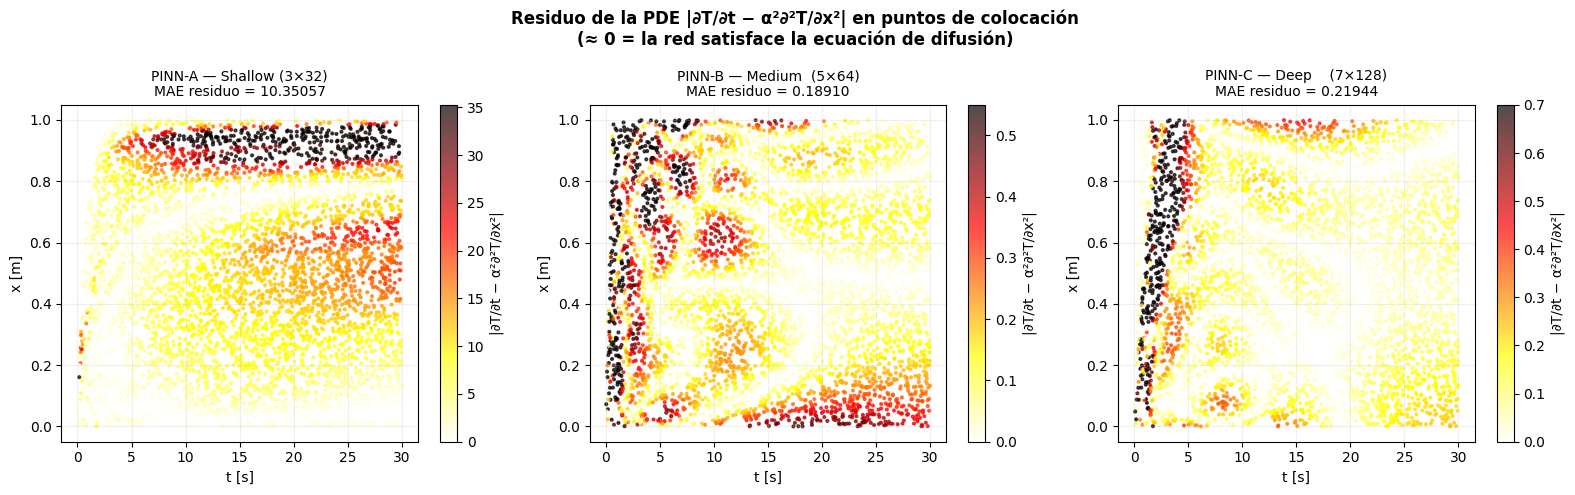

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    res_vals = pinn_residual(
        modelo, t_coll_tf, x_coll_tf
    ).numpy().flatten()

    sc = ax.scatter(t_coll, x_coll,
                    c=np.abs(res_vals), cmap='hot_r', s=4, alpha=0.7,
                    vmin=0, vmax=np.percentile(np.abs(res_vals), 95))
    plt.colorbar(sc, ax=ax, label='|∂T/∂t − α²∂²T/∂x²|')

    ax.set_title(
        f"{etiquetas[nombre]}\n"
        f"MAE residuo = {np.mean(np.abs(res_vals)):.5f}",
        fontsize=10)
    ax.set_xlabel('t [s]', fontsize=10)
    ax.set_ylabel('x [m]', fontsize=10)
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'Residuo de la PDE |∂T/∂t − α²∂²T/∂x²| en puntos de colocación\n'
    '(≈ 0 = la red satisface la ecuación de difusión)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_residuo_PDE.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 15 — Gráfica 8: Análisis de eficiencia (precisión vs costo)

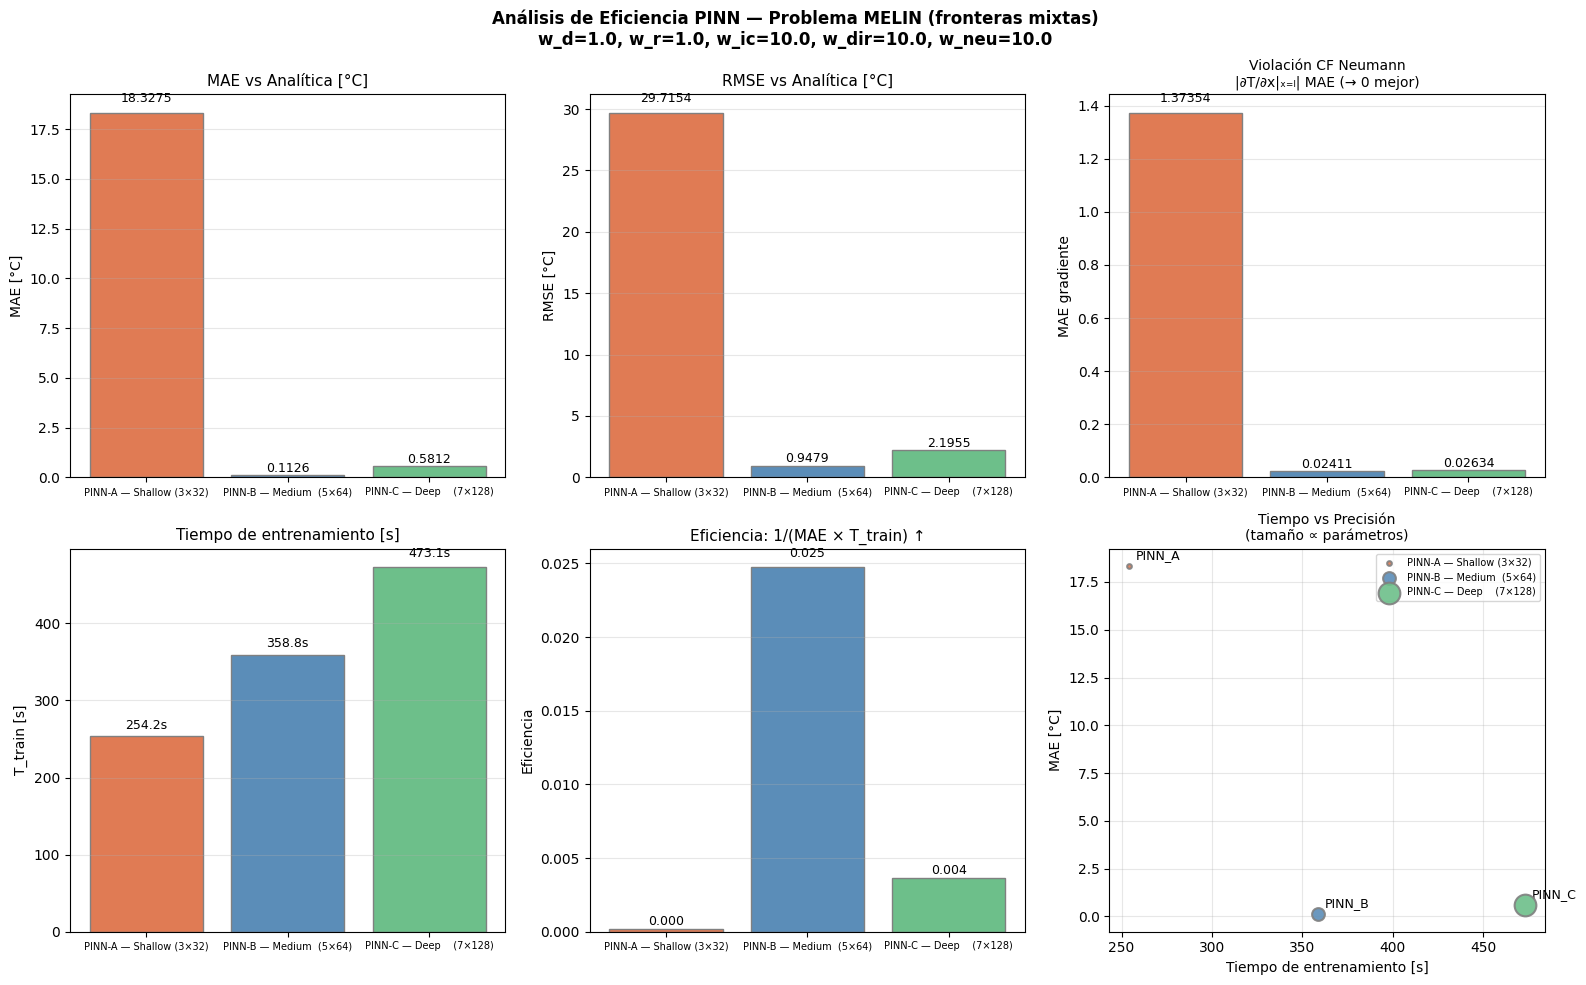

In [15]:
nombres   = list(resultados.keys())
maes      = [resultados[k]['MAE']           for k in nombres]
rmses     = [resultados[k]['RMSE']          for k in nombres]
r2s       = [resultados[k]['R2']            for k in nombres]
t_trains  = [resultados[k]['Tiempo_train']  for k in nombres]
params    = [resultados[k]['Params']        for k in nombres]
neu_maes  = [resultados[k]['Neu_MAE']       for k in nombres]
cols_list = [colores[k] for k in nombres]
labs      = [etiquetas[k] for k in nombres]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── 1. MAE ───────────────────────────────────────────────────
bars = axes[0,0].bar(labs, maes, color=cols_list, edgecolor='gray')
for b, v in zip(bars, maes):
    axes[0,0].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0,0].set_title('MAE vs Analítica [°C]', fontsize=11)
axes[0,0].set_ylabel('MAE [°C]')
axes[0,0].tick_params(axis='x', labelsize=7)
axes[0,0].grid(axis='y', alpha=0.3)

# ── 2. RMSE ──────────────────────────────────────────────────
bars = axes[0,1].bar(labs, rmses, color=cols_list, edgecolor='gray')
for b, v in zip(bars, rmses):
    axes[0,1].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0,1].set_title('RMSE vs Analítica [°C]', fontsize=11)
axes[0,1].set_ylabel('RMSE [°C]')
axes[0,1].tick_params(axis='x', labelsize=7)
axes[0,1].grid(axis='y', alpha=0.3)

# ── 3. Violación de la CF Neumann ─────────────────────────────
bars = axes[0,2].bar(labs, neu_maes, color=cols_list, edgecolor='gray')
for b, v in zip(bars, neu_maes):
    axes[0,2].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.5f}', ha='center', va='bottom', fontsize=9)
axes[0,2].set_title('Violación CF Neumann\n|∂T/∂x|ₓ₌ₗ| MAE (→ 0 mejor)',
                    fontsize=10)
axes[0,2].set_ylabel('MAE gradiente')
axes[0,2].tick_params(axis='x', labelsize=7)
axes[0,2].grid(axis='y', alpha=0.3)

# ── 4. Tiempo de entrenamiento ────────────────────────────────
bars = axes[1,0].bar(labs, t_trains, color=cols_list, edgecolor='gray')
for b, v in zip(bars, t_trains):
    axes[1,0].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.1f}s', ha='center', va='bottom', fontsize=9)
axes[1,0].set_title('Tiempo de entrenamiento [s]', fontsize=11)
axes[1,0].set_ylabel('T_train [s]')
axes[1,0].tick_params(axis='x', labelsize=7)
axes[1,0].grid(axis='y', alpha=0.3)

# ── 5. Eficiencia ─────────────────────────────────────────────
eficiencia = [1/(mae*t) for mae, t in zip(maes, t_trains)]
bars = axes[1,1].bar(labs, eficiencia, color=cols_list, edgecolor='gray')
for b, v in zip(bars, eficiencia):
    axes[1,1].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[1,1].set_title('Eficiencia: 1/(MAE × T_train) ↑', fontsize=11)
axes[1,1].set_ylabel('Eficiencia')
axes[1,1].tick_params(axis='x', labelsize=7)
axes[1,1].grid(axis='y', alpha=0.3)

# ── 6. Scatter tiempo vs MAE (tamaño = parámetros) ───────────
for k, col in zip(nombres, cols_list):
    axes[1,2].scatter(
        resultados[k]['Tiempo_train'],
        resultados[k]['MAE'],
        s=resultados[k]['Params']/200,
        color=col, edgecolors='gray', linewidth=1.5,
        alpha=0.9, label=etiquetas[k], zorder=5)
    axes[1,2].annotate(
        k,
        (resultados[k]['Tiempo_train'], resultados[k]['MAE']),
        textcoords='offset points', xytext=(5,5), fontsize=9)
axes[1,2].set_xlabel('Tiempo de entrenamiento [s]', fontsize=10)
axes[1,2].set_ylabel('MAE [°C]', fontsize=10)
axes[1,2].set_title('Tiempo vs Precisión\n(tamaño ∝ parámetros)', fontsize=10)
axes[1,2].legend(fontsize=7)
axes[1,2].grid(True, alpha=0.3)

fig.suptitle(
    f'Análisis de Eficiencia PINN — Problema MELIN (fronteras mixtas)\n'
    f'w_d={W_DATA}, w_r={W_PDE}, w_ic={W_IC}, '
    f'w_dir={W_BC_DIR}, w_neu={W_BC_NEU}',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_eficiencia_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 16 — Gráfica 9: Convergencia comparada y composición de pérdida

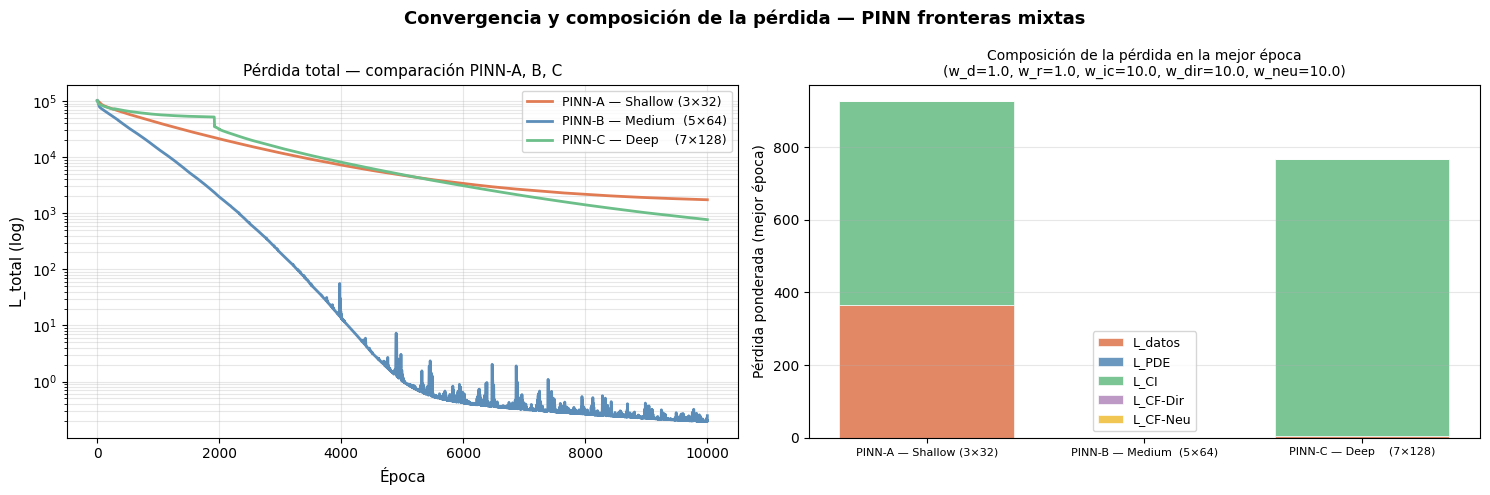

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel izquierdo: pérdida total ───────────────────────────
for nombre, hist in historiales.items():
    ep = range(1, len(hist['total'])+1)
    axes[0].semilogy(ep, hist['total'],
                     color=colores[nombre], lw=2,
                     label=etiquetas[nombre])
axes[0].set_xlabel('Época', fontsize=11)
axes[0].set_ylabel('L_total (log)', fontsize=11)
axes[0].set_title('Pérdida total — comparación PINN-A, B, C', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, which='both', alpha=0.3)

# ── Panel derecho: barra apilada por componente ───────────────
labels_comp  = ['L_datos', 'L_PDE', 'L_CI', 'L_CF-Dir', 'L_CF-Neu']
weights_comp = [W_DATA, W_PDE, W_IC, W_BC_DIR, W_BC_NEU]
keys_comp    = ['data', 'pde', 'ic', 'bc_dir', 'bc_neu']
colors_comp  = ['#E07B54', '#5B8DB8', '#6DBF8A', '#B68FBF', '#F0C040']

data_comp = np.array([
    [w * min(historiales[k][c])
     for w, c in zip(weights_comp, keys_comp)]
    for k in nombres
])

x_pos  = np.arange(len(nombres))
bottom = np.zeros(len(nombres))
for j, (lc, cc) in enumerate(zip(labels_comp, colors_comp)):
    axes[1].bar(x_pos, data_comp[:,j], bottom=bottom,
                color=cc, edgecolor='white', lw=0.5,
                label=lc, alpha=0.9)
    bottom += data_comp[:,j]

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([etiquetas[k] for k in nombres], fontsize=8)
axes[1].set_ylabel('Pérdida ponderada (mejor época)', fontsize=10)
axes[1].set_title(
    'Composición de la pérdida en la mejor época\n'
    f'(w_d={W_DATA}, w_r={W_PDE}, w_ic={W_IC}, w_dir={W_BC_DIR}, w_neu={W_BC_NEU})',
    fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Convergencia y composición de la pérdida — PINN fronteras mixtas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_convergencia_comparada.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 17 — Visualización de las arquitecturas PINN

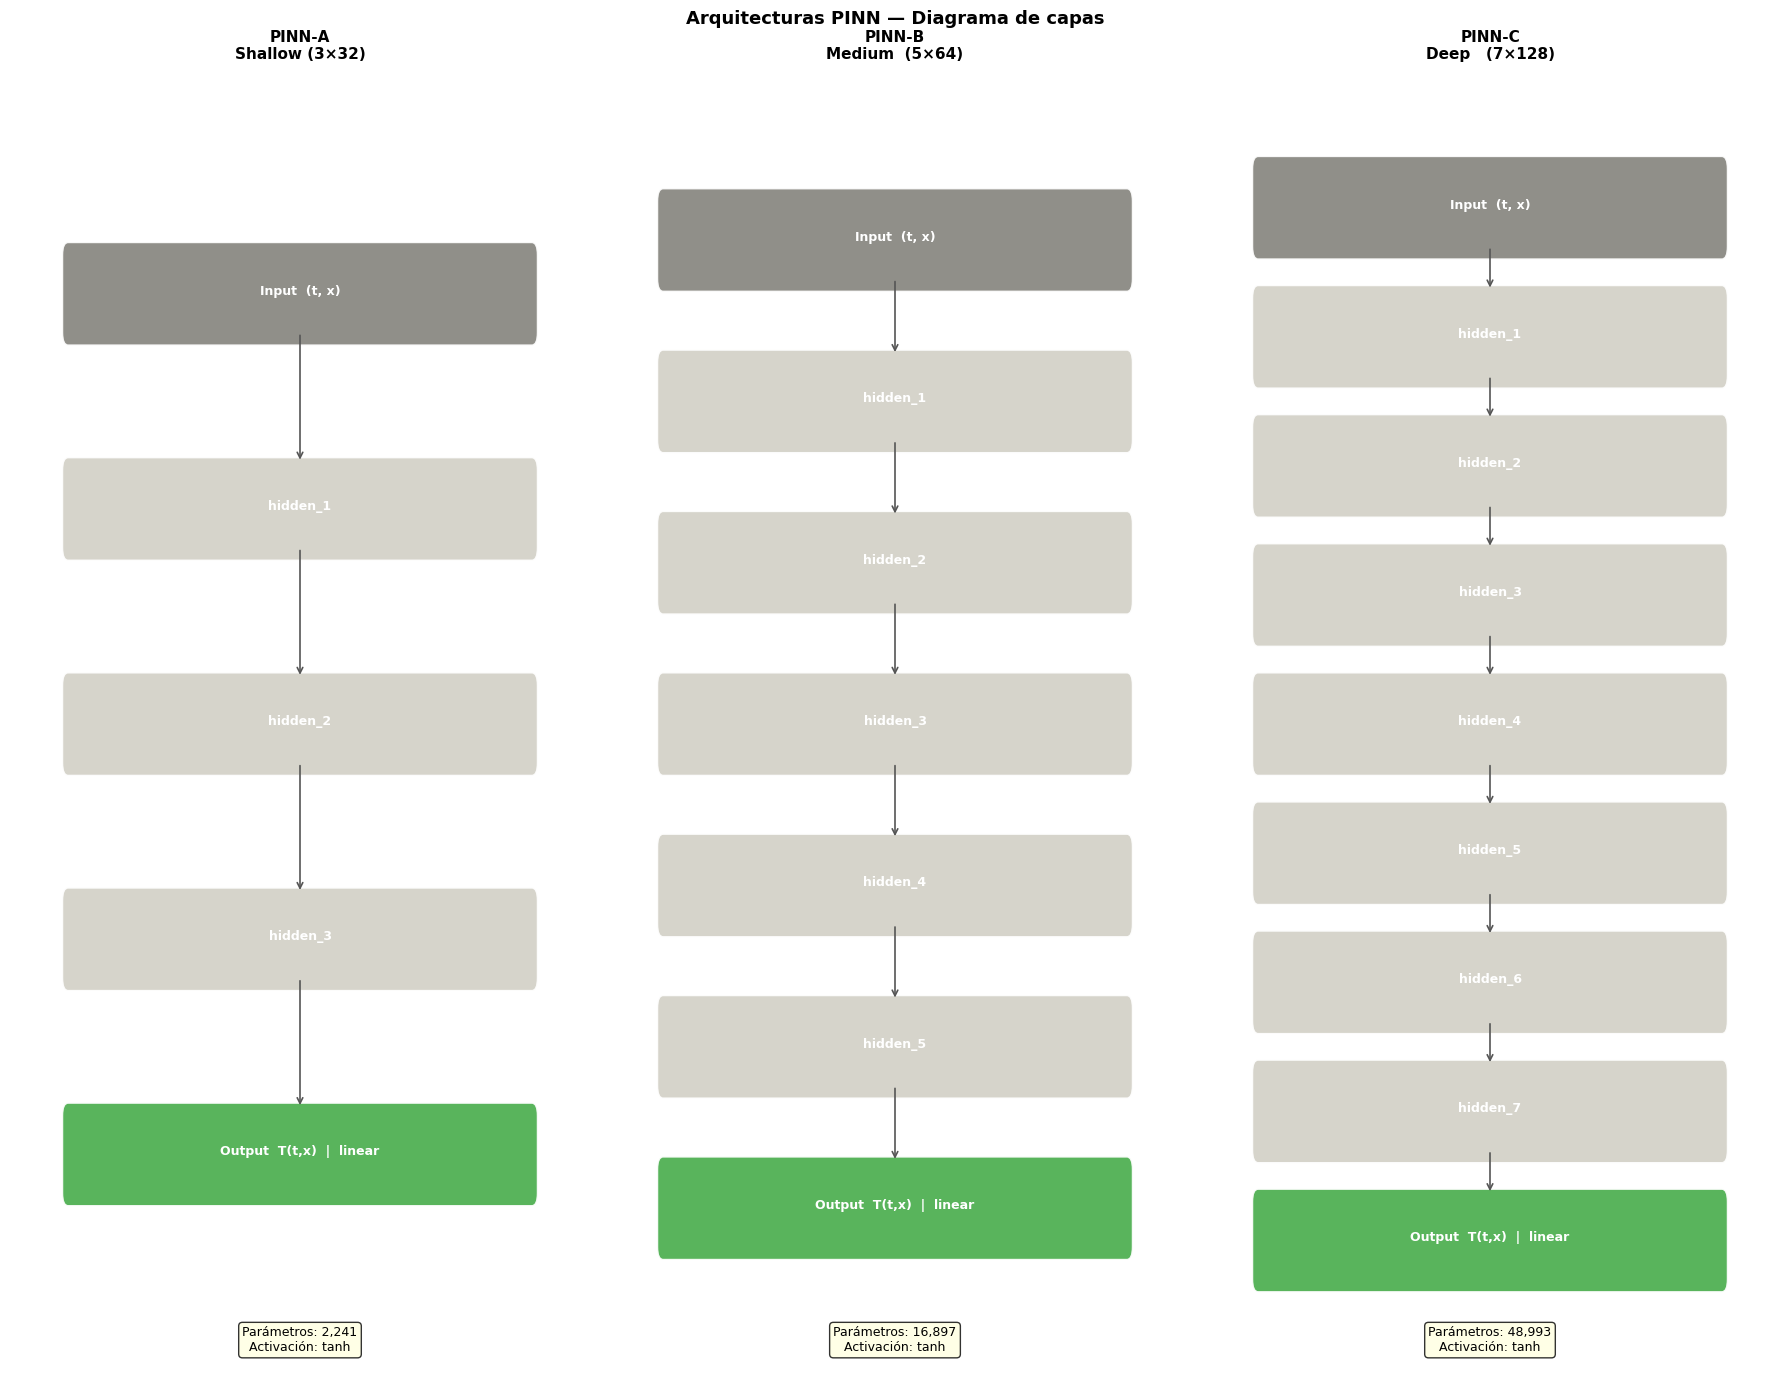

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 14))

arq_info = [
    ('PINN-A\nShallow (3×32)', model_A, '#7F77DD'),
    ('PINN-B\nMedium  (5×64)', model_B, '#D85A30'),
    ('PINN-C\nDeep   (7×128)', model_C, '#378ADD'),
]

for ax, (titulo, modelo, color_base) in zip(axes, arq_info):
    ax.axis('off')
    capas  = list(modelo.layers)
    n      = len(capas)
    y_step = 1.0 / (n + 1)

    for idx, capa in enumerate(capas):
        y   = 1.0 - (idx+1)*y_step
        cfg = capa.get_config()
        name = capa.name

        if 'input' in name:
            color = '#888780'; texto = 'Input  (t, x)'
        elif 'output' in name:
            color = '#4CAF50'; texto = 'Output  T(t,x)  |  linear'
        elif 'dense' in name:
            units = cfg.get('units','?')
            act   = cfg.get('activation','')
            color = color_base
            texto = f'Dense {units}  |  {act}'
        else:
            color = '#D3D1C7'; texto = name

        rect = mpatches.FancyBboxPatch(
            (0.10, y-0.032), 0.80, 0.060,
            boxstyle='round,pad=0.01',
            facecolor=color, edgecolor='white',
            linewidth=1.5, alpha=0.93,
            transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)
        ax.text(0.50, y, texto,
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold',
                transform=ax.transAxes)

        if idx < n-1:
            ax.annotate('',
                xy=(0.50, y - y_step + 0.034),
                xytext=(0.50, y - 0.032),
                xycoords='axes fraction',
                textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=12)
    ax.text(0.50, 0.01,
            f'Parámetros: {modelo.count_params():,}\nActivación: tanh',
            ha='center', va='bottom', fontsize=9,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Arquitecturas PINN — Diagrama de capas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_arquitecturas.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 18 — Ranking final y conclusión

In [18]:
df_final = pd.DataFrame({
    'Modelo'             : [etiquetas[k]                            for k in resultados],
    'Parámetros'         : [resultados[k]['Params']                  for k in resultados],
    'Épocas'             : [resultados[k]['Epocas']                  for k in resultados],
    'MAE [°C]'           : [round(resultados[k]['MAE'],    5)        for k in resultados],
    'RMSE [°C]'          : [round(resultados[k]['RMSE'],   5)        for k in resultados],
    'R²'                 : [round(resultados[k]['R2'],     6)        for k in resultados],
    'MaxErr [°C]'        : [round(resultados[k]['Max_Error'], 3)     for k in resultados],
    '|∂T/∂x|_L| MAE'    : [round(resultados[k]['Neu_MAE'],   5)     for k in resultados],
    'T_train [s]'        : [round(resultados[k]['Tiempo_train'], 2)  for k in resultados],
})

df_final = df_final.sort_values('MAE [°C]').reset_index(drop=True)
df_final.index = df_final.index + 1
df_final.index.name = 'Rank'

print('\n' + '='*80)
print('  RANKING FINAL — PROBLEMA MELIN (FRONTERAS MIXTAS)')
print('='*80)
display(df_final)

print(f'\n  Configuración de pesos:')
print(f'    w_data   = {W_DATA}   (datos supervisados)')
print(f'    w_pde    = {W_PDE}   (residuo PDE)')
print(f'    w_ic     = {W_IC}  (CI: T(x,0) = 100°C uniforme)')
print(f'    w_bc_dir = {W_BC_DIR}  (CF Dirichlet: T(0,t) = 0)')
print(f'    w_bc_neu = {W_BC_NEU}  (CF Neumann:   ∂T/∂x|_{{x=L}} = 0)')
print()
print('  Archivos guardados:')
for f in [
    'pinn_perdida_componentes.png',
    'pinn_scatter.png',
    'pinn_superficies.png',
    'pinn_perfiles_temp.png',
    'pinn_evolucion_temporal.png',
    'pinn_neumann_check.png',
    'pinn_residuo_PDE.png',
    'pinn_eficiencia_comparativa.png',
    'pinn_convergencia_comparada.png',
    'pinn_arquitecturas.png',
]:
    print(f'    {f}')


  RANKING FINAL — PROBLEMA MELIN (FRONTERAS MIXTAS)


,Modelo,Parámetros,Épocas,MAE [°C],RMSE [°C],R²,MaxErr [°C],|∂T/∂x|_L| MAE,T_train [s]
Rank,,,,,,,,,
1,PINN-B — Medium (5×64),16897,10000,0.11260,0.94786,0.998727,99.540001,0.02411,358.75
2,PINN-C — Deep (7×128),48993,10000,0.58124,2.19554,0.993168,91.218002,0.02634,473.10
3,PINN-A — Shallow (3×32),2241,10000,18.32751,29.71544,-0.251457,89.014999,1.37354,254.19



  Configuración de pesos:
    w_data   = 1.0   (datos supervisados)
    w_pde    = 1.0   (residuo PDE)
    w_ic     = 10.0  (CI: T(x,0) = 100°C uniforme)
    w_bc_dir = 10.0  (CF Dirichlet: T(0,t) = 0)
    w_bc_neu = 10.0  (CF Neumann:   ∂T/∂x|_{x=L} = 0)

  Archivos guardados:
    pinn_perdida_componentes.png
    pinn_scatter.png
    pinn_superficies.png
    pinn_perfiles_temp.png
    pinn_evolucion_temporal.png
    pinn_neumann_check.png
    pinn_residuo_PDE.png
    pinn_eficiencia_comparativa.png
    pinn_convergencia_comparada.png
    pinn_arquitecturas.png
